<div style="display: flex; align-items: center; justify-content: flex-start; text-align: left;">
    <img src="https://upload.wikimedia.org/wikipedia/commons/thumb/6/68/Logo_universidad_icesi.svg/960px-Logo_universidad_icesi.svg.png" width="300" style="margin-right: 20px;">
    <div>
        <h3 style="margin: 0;">FACULTAD BARBERI DE INGENIERÍA, DISEÑO Y CIENCIAS APLICADAS</h3>
        <h3 style="margin: 0;">ALGORITMOS Y PROGRAMACIÓN III</h3>
    </div>
</div>

# Proyecto Final

Integrantes:
- ANGY MARIA HURTADO OSORIO A00401755
- HIDEKI TAMURA HERNANDEZ A00348618
- DAVID VERGARA LAVERDE A00402237


## Modelado - Experimentos de Deep Learning (CNN)

Este notebook se enfoca en la construcción de una Red Neuronal Convolucional (CNN) personalizada utilizando **TensorFlow/Keras**. El objetivo es crear un modelo de múltiples salidas (multi-output) que reciba la imagen original y prediga simultáneamente la **Calidad** y el **Tamaño**.

In [1]:
import sys
import os
import pandas as pd
import cv2
from tqdm import tqdm
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split

# TensorFlow y Keras para Deep Learning
import tensorflow as tf
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Conv2D, MaxPooling2D, Flatten, Dense, Dropout, GlobalAveragePooling2D
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau

# Añadir la carpeta raíz al path para importar src
sys.path.append(os.path.abspath('..'))
from src.evaluation.evaluate import evaluate_multioutput_model

I0000 00:00:1780725999.963116    5771 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1780726000.325230    5771 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1780726001.717909    5771 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


In [2]:
gpus = tf.config.list_physical_devices('GPU')
print("GPUs disponibles:", gpus)
# Debe imprimir algo como:
# GPUs disponibles: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]

# Evitar que TensorFlow acapare toda la VRAM de una vez
if gpus:
    tf.config.experimental.set_memory_growth(gpus[0], True)
    print("Memory growth activado ✅")
else:
    print("⚠️ No se detectó GPU, se usará CPU")

GPUs disponibles: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]
Memory growth activado ✅


### 1. Carga de Datos y Preprocesamiento de Imágenes

Para Deep Learning, en lugar de features extraídos manualmente, introducimos los píxeles de las imágenes redimensionadas (ej. 128x128x3). Aquí generaremos un conjunto de datos ficticio con tensores 4D para poder estructurar y probar la arquitectura.

In [3]:
# TODO: Utilizar `tf.keras.preprocessing.image_dataset_from_directory` o src.utils.helpers para la carga real
IMG_HEIGHT = 224
IMG_WIDTH  = 224
BASE_PATH  = '../data/processed/'

metadata = pd.read_csv('../data/processed/metadata.csv')
size_map = {'small': 0, 'medium': 1, 'large': 2}
metadata['size_label'] = metadata['size_category'].map(size_map)

metadata_original  = metadata[metadata['augmented'] == 0].copy().reset_index(drop=True)
metadata_augmented = metadata[metadata['augmented'] == 1].copy().reset_index(drop=True)

# Split limpio: test SOLO con originales
meta_train_orig, meta_test = train_test_split(
    metadata_original, test_size=0.2, random_state=42,
    stratify=metadata_original['label']
)

# Train = originales + aumentadas
meta_train = pd.concat([meta_train_orig, metadata_augmented]).reset_index(drop=True)
meta_test  = meta_test.reset_index(drop=True)

print(f"Train: {len(meta_train)} imágenes")
print(f"Test:  {len(meta_test)} imágenes")
print(f"Distribución calidad train:\n{meta_train['quality'].value_counts()}")

# --- Generador que carga imágenes por lotes (no carga todo en RAM) ---
def make_dataset(df, batch_size=64, shuffle=True):
    paths    = (BASE_PATH + df['file']).values
    labels_q = df['label'].values.astype('int32')
    labels_s = df['size_label'].values.astype('int32')

    def load_image(path, lq, ls):
        img = tf.io.read_file(path)
        img = tf.image.decode_jpeg(img, channels=3)
        img = tf.image.resize(img, [IMG_HEIGHT, IMG_WIDTH])
        img = tf.cast(img, tf.float32) / 255.0
        return img, {'quality_output': lq, 'size_output': ls}

    ds = tf.data.Dataset.from_tensor_slices((paths, labels_q, labels_s))
    if shuffle:
        ds = ds.shuffle(buffer_size=1000, seed=42)
    ds = ds.map(load_image, num_parallel_calls=tf.data.AUTOTUNE)
    ds = ds.batch(batch_size)
    ds = ds.prefetch(tf.data.AUTOTUNE)  # GPU y CPU trabajan en paralelo
    return ds

BATCH_SIZE = 64

train_ds = make_dataset(meta_train, batch_size=BATCH_SIZE, shuffle=True)
test_ds  = make_dataset(meta_test,  batch_size=BATCH_SIZE, shuffle=False)

print(f"\nBatches en train: {len(train_ds)}")
print(f"Batches en test:  {len(test_ds)}")

Train: 136296 imágenes
Test:  5679 imágenes
Distribución calidad train:
quality
Good       70075
Bad        43882
Regular    22339
Name: count, dtype: int64


I0000 00:00:1780726007.258124    5771 gpu_device.cc:2043] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 6147 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 4060 Laptop GPU, pci bus id: 0000:01:00.0, compute capability: 8.9



Batches en train: 2130
Batches en test:  89


### 2. Definición de la Arquitectura CNN Bifurcada (Multi-Output)

Diseñamos una red con un **tronco común** (Common Feature Extractor) compuesto por capas convolucionales para aprender patrones visuales generales (bordes, colores, texturas). Luego, la red se divide en **dos ramas (cabezas)**: una para predecir la calidad y otra para el tamaño.

In [4]:
def build_multioutput_cnn(input_shape=(224, 224, 3), num_quality_classes=3, num_size_classes=3):
    # --- Tronco Común (Feature Extractor) ---
    inputs = Input(shape=input_shape, name='imagen_entrada')
    
    x = Conv2D(32, (3, 3), activation='relu', padding='same')(inputs)
    x = MaxPooling2D((2, 2))(x)
    
    x = Conv2D(64, (3, 3), activation='relu', padding='same')(x)
    x = MaxPooling2D((2, 2))(x)
    
    x = Conv2D(128, (3, 3), activation='relu', padding='same')(x)
    x = MaxPooling2D((2, 2))(x)
    
    # Usamos GlobalAveragePooling en lugar de Flatten para reducir parámetros y mitigar overfitting
    x = GlobalAveragePooling2D()(x)
    x = Dropout(0.4)(x) # Regularización
    
    # --- Rama 1: Predicción de Calidad ---
    quality_branch = Dense(64, activation='relu')(x)
    quality_branch = Dropout(0.3)(quality_branch)
    quality_output = Dense(num_quality_classes, activation='softmax', name='quality_output')(quality_branch)
    
    # --- Rama 2: Predicción de Tamaño ---
    size_branch = Dense(64, activation='relu')(x)
    size_branch = Dropout(0.3)(size_branch)
    size_output = Dense(num_size_classes, activation='softmax', name='size_output')(size_branch)
    
    # --- Ensamblaje del Modelo ---
    model = Model(inputs=inputs, outputs=[quality_output, size_output], name='MultiOutput_CNN')
    return model

cnn_model = build_multioutput_cnn()
cnn_model.summary()

Model: "MultiOutput_CNN"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ imagen_entrada      │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d (Conv2D)     │ (None, 224, 224,  │        896 │ imagen_entrada[0… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d       │ (None, 112, 112,  │          0 │ conv2d[0][0]      │
│ (MaxPooling2D)      │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_1 (Conv2D)   │ (None, 112, 112,  │     18,496 │ max_pooling2d[0]… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_1     │ (None, 56, 56,    │          0 │ conv2d_1[0][0]    │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_2 (Conv2D)   │ (None, 56, 56,    │     73,856 │ max_pooling2d_1[… │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_2     │ (None, 28, 28,    │          0 │ conv2d_2[0][0]    │
│ (MaxPooling2D)      │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_average_poo… │ (None, 128)       │          0 │ max_pooling2d_2[… │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout (Dropout)   │ (None, 128)       │          0 │ global_average_p… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 64)        │      8,256 │ dropout[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1 (Dense)     │ (None, 64)        │      8,256 │ dropout[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_1 (Dropout) │ (None, 64)        │          0 │ dense[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_2 (Dropout) │ (None, 64)        │          0 │ dense_1[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ quality_output      │ (None, 3)         │        195 │ dropout_1[0][0]   │
│ (Dense)             │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ size_output (Dense) │ (None, 3)         │        195 │ dropout_2[0][0]   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 110,150 (430.27 KB)

 Trainable params: 110,150 (430.27 KB)

 Non-trainable params: 0 (0.00 B)

### 3. Compilación del Modelo

Configuramos la función de pérdida (`loss`) para ambas salidas y asignamos pesos a cada pérdida si fuera necesario. En este caso daremos el mismo peso (1.0) a ambas tareas.

In [5]:
cnn_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss={
        'quality_output': 'sparse_categorical_crossentropy',
        'size_output': 'sparse_categorical_crossentropy'
    },
    loss_weights={
        'quality_output': 1.0,
        'size_output': 1.0
    },
    metrics={
        'quality_output': ['accuracy'],
        'size_output': ['accuracy']
    }
)

### 4. Entrenamiento con Callbacks (Previniendo Overfitting)

Añadimos `EarlyStopping` para detener el entrenamiento si la métrica en validación no mejora, y `ReduceLROnPlateau` para reducir la tasa de aprendizaje si el modelo se estanca.

In [6]:
callbacks = [
    EarlyStopping(patience=5, restore_best_weights=True, monitor='val_loss'),
    ReduceLROnPlateau(factor=0.5, patience=3, monitor='val_loss'),
    ModelCheckpoint(
        filepath='../models/cnn_best_checkpoint.keras',
        save_best_only=True,
        monitor='val_loss'
    )
]

history = cnn_model.fit(
    train_ds,                       
    validation_data=test_ds,           
    epochs=30,
    callbacks=callbacks,
    verbose=1
)

Epoch 1/30


I0000 00:00:1780726042.749806    7117 service.cc:153] XLA service 0x55a6567d7080 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1780726042.749829    7117 service.cc:161]   StreamExecutor [0]: NVIDIA GeForce RTX 4060 Laptop GPU, Compute Capability 8.9 (Driver: 13.0.0; Runtime: 12.9.0; Toolkit: 12.5.0; DNN: 9.23.0)
I0000 00:00:1780726042.804959    7117 dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
I0000 00:00:1780726042.982007    7117 cuda_dnn.cc:461] Loaded cuDNN version 92300
I0000 00:00:1780726043.029676    7117 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_3150__.54
I0000 00:00:1780726044.103792    7117 dot_search_space.cc:240] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a good representative set of valid configs? Working around this by using the full hints set i

   2/2130 ━━━━━━━━━━━━━━━━━━━━ 2:46 78ms/step - loss: 2.2144 - quality_output_accuracy: 0.2422 - quality_output_loss: 1.1373 - size_output_accuracy: 0.4766 - size_output_loss: 1.0771  

I0000 00:00:1780726051.401632    7117 device_compiler.h:208] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


2129/2130 ━━━━━━━━━━━━━━━━━━━━ 0s 77ms/step - loss: 0.8620 - quality_output_accuracy: 0.8030 - quality_output_loss: 0.4322 - size_output_accuracy: 0.8148 - size_output_loss: 0.4298

I0000 00:00:1780726214.575182    7117 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_3150__.54
I0000 00:00:1780726214.864049    7117 dot_search_space.cc:240] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a good representative set of valid configs? Working around this by using the full hints set instead.
I0000 00:00:1780726215.103206    8068 subprocess_compilation.cc:348] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_MatMul_30', 12 bytes spill stores, 12 bytes spill loads

I0000 00:00:1780726215.944547    7117 dot_search_space.cc:240] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a good representative set of valid configs? Working around this by using the full hints set instead.
I0000 00:00:1780726216.159557    8071 subprocess_compilation.cc:348] ptxas warning : Registers are spilled

2130/2130 ━━━━━━━━━━━━━━━━━━━━ 0s 80ms/step - loss: 0.8619 - quality_output_accuracy: 0.8031 - quality_output_loss: 0.4321 - size_output_accuracy: 0.8148 - size_output_loss: 0.4298

I0000 00:00:1780726221.318445    7117 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_18468__.26
I0000 00:00:1780726221.331027    7117 dot_search_space.cc:240] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a good representative set of valid configs? Working around this by using the full hints set instead.
I0000 00:00:1780726224.747953    7114 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_18468__.26
I0000 00:00:1780726224.755265    7114 dot_search_space.cc:240] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a good representative set of valid configs? Working around this by using the full hints set instead.
I0000 00:00:1780726224.992286    8439 subprocess_compilation.cc:348] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot', 28 bytes spill stores, 28 byte

2130/2130 ━━━━━━━━━━━━━━━━━━━━ 185s 82ms/step - loss: 0.5022 - quality_output_accuracy: 0.9237 - quality_output_loss: 0.1780 - size_output_accuracy: 0.8624 - size_output_loss: 0.3242 - val_loss: 9.2723 - val_quality_output_accuracy: 0.1639 - val_quality_output_loss: 8.9723 - val_size_output_accuracy: 0.8748 - val_size_output_loss: 0.2999 - learning_rate: 0.0010
Epoch 2/30
2130/2130 ━━━━━━━━━━━━━━━━━━━━ 163s 76ms/step - loss: 0.4566 - quality_output_accuracy: 0.9305 - quality_output_loss: 0.1795 - size_output_accuracy: 0.8834 - size_output_loss: 0.2770 - val_loss: 10.6022 - val_quality_output_accuracy: 0.1639 - val_quality_output_loss: 9.9073 - val_size_output_accuracy: 0.7956 - val_size_output_loss: 0.6963 - learning_rate: 0.0010
Epoch 3/30
2130/2130 ━━━━━━━━━━━━━━━━━━━━ 162s 76ms/step - loss: 0.5347 - quality_output_accuracy: 0.9228 - quality_output_loss: 0.1987 - size_output_accuracy: 0.8591 - size_output_loss: 0.3360 - val_loss: 10.4051 - val_quality_output_accuracy: 0.1639 - val_qu

### 5. Curvas de Aprendizaje

Es crucial graficar la pérdida global (loss) para detectar visualmente el sobreajuste.

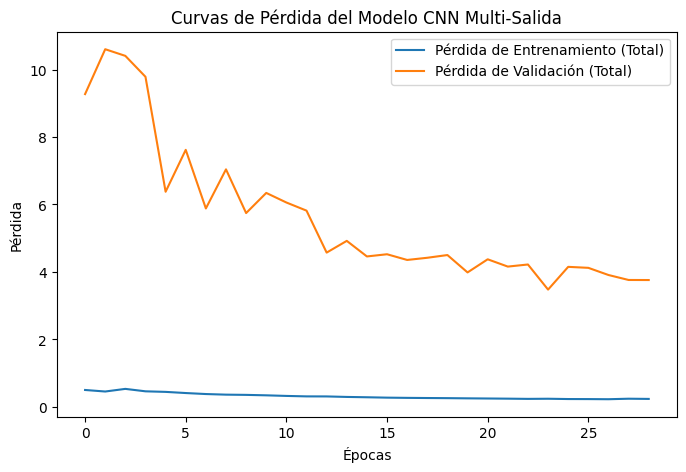

In [7]:
plt.figure(figsize=(8, 5))
plt.plot(history.history['loss'], label='Pérdida de Entrenamiento (Total)')
plt.plot(history.history['val_loss'], label='Pérdida de Validación (Total)')
plt.title('Curvas de Pérdida del Modelo CNN Multi-Salida')
plt.xlabel('Épocas')
plt.ylabel('Pérdida')
plt.legend()
plt.show()

### 6. Evaluación del Modelo

Realizamos las predicciones sobre el conjunto de test. Keras nos devolverá una lista con dos arrays de probabilidades (uno para calidad y otro para tamaño). Tomaremos el `argmax` para obtener la clase y lo pasaremos a nuestra función centralizada.

I0000 00:00:1780730880.889557    7113 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_457235__.12
I0000 00:00:1780730887.988160    7113 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_465970__.12


REPORTE DE CLASIFICACIÓN: CALIDAD
              precision    recall  f1-score   support

        Mala       1.00      0.00      0.00      1828
       Buena       0.98      0.29      0.45      2920
     Regular       0.19      1.00      0.32       931

    accuracy                           0.32      5679
   macro avg       0.73      0.43      0.26      5679
weighted avg       0.86      0.32      0.29      5679

REPORTE DE CLASIFICACIÓN: TAMAÑO
              precision    recall  f1-score   support

     Pequeño       0.96      0.83      0.89       504
     Mediano       0.80      0.99      0.88      2143
      Grande       1.00      0.85      0.92      3032

    accuracy                           0.90      5679
   macro avg       0.92      0.89      0.90      5679
weighted avg       0.92      0.90      0.90      5679



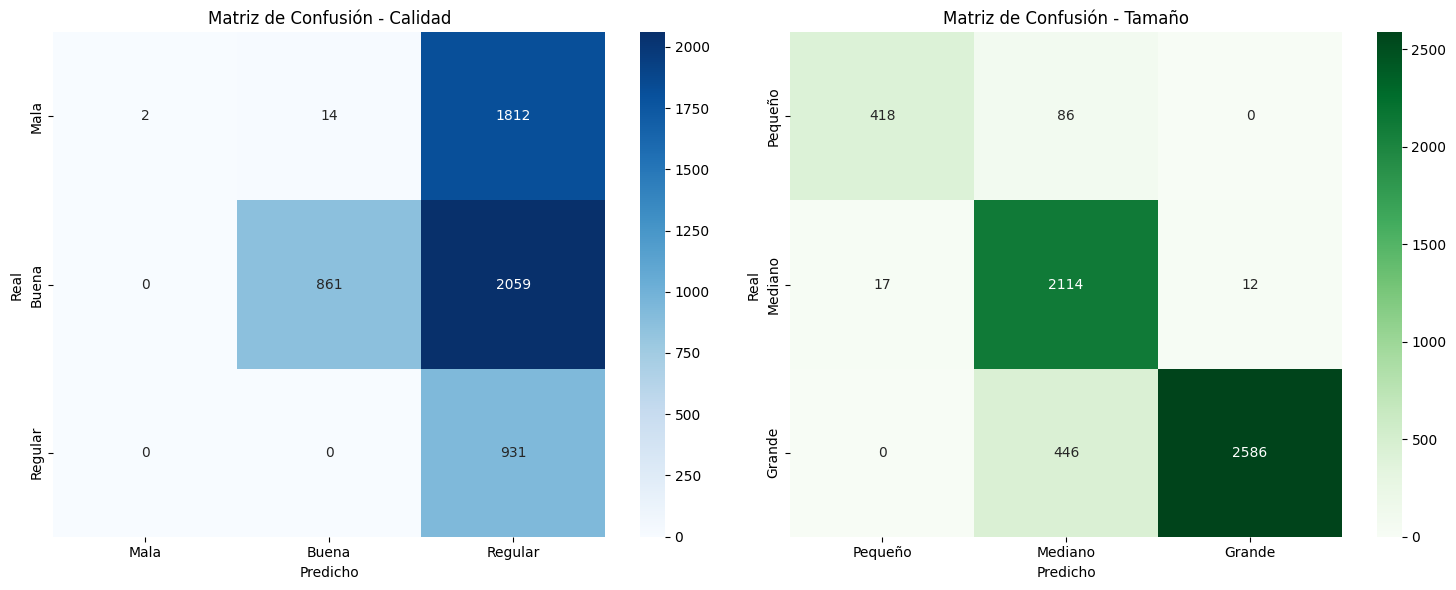

In [8]:
y_test_qual, y_test_size = [], []
y_pred_quality, y_pred_size = [], []

for X_batch, y_batch in test_ds:
    preds = cnn_model.predict(X_batch, verbose=0)
    y_pred_quality.extend(np.argmax(preds[0], axis=1))
    y_pred_size.extend(np.argmax(preds[1], axis=1))
    y_test_qual.extend(y_batch['quality_output'].numpy())
    y_test_size.extend(y_batch['size_output'].numpy())

y_test_qual    = np.array(y_test_qual)
y_test_size    = np.array(y_test_size)
y_pred_quality = np.array(y_pred_quality)
y_pred_size    = np.array(y_pred_size)

quality_names = ['Mala', 'Buena', 'Regular']
size_names = ['Pequeño', 'Mediano', 'Grande']

# Evaluación usando src/evaluation/evaluate.py
evaluate_multioutput_model(
    y_test_qual, y_pred_quality,
    y_test_size, y_pred_size,
    quality_classes=quality_names,
    size_classes=size_names
)

### 7. Guardar el Modelo Entrenado

Guardamos el modelo en formato `.h5` o `SavedModel` de Keras para su despliegue en la aplicación web.

In [ ]:
model_dir = '../models'
os.makedirs(model_dir, exist_ok=True)
model_path = os.path.join(model_dir, 'cnn_multioutput.keras') # Se recomienda .keras en nuevas versiones

cnn_model.save(model_path)
print(f"Modelo de Deep Learning guardado exitosamente en: {model_path}")